# Notebook 03 — Comparing Cardiac Phenotypes

## Goal

Analyze the ACDC training cohort and compare cardiac structure and
function across phenotype groups.

This notebook will:

1. Load metadata and ED/ES segmentations for every training patient.
2. Calculate LV and RV functional metrics.
3. Build a patient-level analysis dataframe.
4. Compare metric distributions across ACDC groups.
5. Select representative patients from each group.
6. Compare representative hearts using 2D and 3D visualizations.

This notebook uses the provided expert segmentation masks rather than
automatically predicted segmentations.

In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from skimage.measure import marching_cubes

In [2]:
DATA_DIR = Path("../data/training")

In [3]:
BACKGROUND = 0
RV = 1
MYOCARDIUM = 2
LV = 3

In [4]:
def read_patient_info(patient_dir):
    info = {}

    with open(patient_dir / "Info.cfg", "r") as f:
        for line in f:
            if ":" in line:
                key, value = line.strip().split(":", 1)
                info[key.strip()] = value.strip()

    return info

In [5]:
def mask_volume_ml(mask, spacing):
    voxel_volume_mm3 = np.prod(spacing)
    volume_mm3 = np.sum(mask) * voxel_volume_mm3

    return volume_mm3 / 1000

In [6]:
def ventricular_metrics(ed_gt, es_gt, spacing, label):
    ed_mask = ed_gt == label
    es_mask = es_gt == label

    edv = mask_volume_ml(ed_mask, spacing)
    esv = mask_volume_ml(es_mask, spacing)

    sv = edv - esv
    ef = (sv / edv) * 100

    return {
        "EDV_mL": edv,
        "ESV_mL": esv,
        "SV_mL": sv,
        "EF_percent": ef
    }

In [7]:
def mask_to_mesh(mask, spacing):
    verts, faces, normals, values = marching_cubes(
        mask.astype(np.uint8),
        level=0.5,
        spacing=spacing
    )

    return verts, faces

In [8]:
patient_records = []

for patient_dir in sorted(DATA_DIR.glob("patient*")):
    info = read_patient_info(patient_dir)

    patient_records.append({
        "Patient": patient_dir.name,
        "Group": info.get("Group"),
        "ED_Frame": int(info["ED"]),
        "ES_Frame": int(info["ES"])
    })

patient_info = pd.DataFrame(patient_records)

patient_info.head()

,Patient,Group,ED_Frame,ES_Frame
0,patient001,DCM,1,12
1,patient002,DCM,1,12
2,patient003,DCM,1,15
3,patient004,DCM,1,15
4,patient005,DCM,1,13


In [9]:
print("Number of patients:", len(patient_info))

Number of patients: 100


In [10]:
patient_info["Group"].value_counts()

Group
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64

In [11]:
sorted(patient_info["Group"].unique())

['DCM', 'HCM', 'MINF', 'NOR', 'RV']

In [12]:
GROUP_NAMES = {
    "NOR": "Normal",
    "MINF": "Myocardial Infarction",
    "DCM": "Dilated Cardiomyopathy",
    "HCM": "Hypertrophic Cardiomyopathy",
    "RV": "Abnormal Right Ventricle"
}

In [13]:
patient_info["Group_Name"] = (
    patient_info["Group"]
    .map(GROUP_NAMES)
    .fillna(patient_info["Group"])
)

In [14]:
def analyze_patient(patient_id):
    patient_dir = DATA_DIR / patient_id

    info = read_patient_info(patient_dir)

    ed_frame = int(info["ED"])
    es_frame = int(info["ES"])

    ed_gt_path = (
        patient_dir /
        f"{patient_id}_frame{ed_frame:02d}_gt.nii.gz"
    )

    es_gt_path = (
        patient_dir /
        f"{patient_id}_frame{es_frame:02d}_gt.nii.gz"
    )

    ed_gt_img = nib.load(ed_gt_path)
    es_gt_img = nib.load(es_gt_path)

    ed_gt = ed_gt_img.get_fdata()
    es_gt = es_gt_img.get_fdata()

    spacing = ed_gt_img.header.get_zooms()[:3]

    lv = ventricular_metrics(
        ed_gt,
        es_gt,
        spacing,
        LV
    )

    rv = ventricular_metrics(
        ed_gt,
        es_gt,
        spacing,
        RV
    )

    myo_ed = mask_volume_ml(
        ed_gt == MYOCARDIUM,
        spacing
    )

    myo_es = mask_volume_ml(
        es_gt == MYOCARDIUM,
        spacing
    )

    return {
        "Patient": patient_id,
        "Group": info.get("Group"),

        "LV_EDV": lv["EDV_mL"],
        "LV_ESV": lv["ESV_mL"],
        "LV_SV": lv["SV_mL"],
        "LV_EF": lv["EF_percent"],

        "RV_EDV": rv["EDV_mL"],
        "RV_ESV": rv["ESV_mL"],
        "RV_SV": rv["SV_mL"],
        "RV_EF": rv["EF_percent"],

        "MYO_ED_Volume": myo_ed,
        "MYO_ES_Volume": myo_es
    }

In [15]:
test_result = analyze_patient("patient001")
test_result

{'Patient': 'patient001',
 'Group': 'DCM',
 'LV_EDV': np.float64(295.5078125),
 'LV_ESV': np.float64(225.6103515625),
 'LV_SV': np.float64(69.8974609375),
 'LV_EF': np.float64(23.65333773959022),
 'RV_EDV': np.float64(139.7216796875),
 'RV_ESV': np.float64(59.5458984375),
 'RV_SV': np.float64(80.17578125),
 'RV_EF': np.float64(57.38249170015726),
 'MYO_ED_Volume': np.float64(164.2578125),
 'MYO_ES_Volume': np.float64(195.068359375)}

In [16]:
results = []
failed_patients = []

for patient_dir in sorted(DATA_DIR.glob("patient*")):
    patient_id = patient_dir.name

    try:
        results.append(
            analyze_patient(patient_id)
        )

    except Exception as e:
        failed_patients.append(
            (patient_id, str(e))
        )

In [17]:
results_df = pd.DataFrame(results)

print("Successfully processed:", len(results_df))
print("Failed:", len(failed_patients))

Successfully processed: 100
Failed: 0


In [18]:
results_df["Group_Name"] = (
    results_df["Group"]
    .map(GROUP_NAMES)
    .fillna(results_df["Group"])
)

In [19]:
results_df.head()

,Patient,Group,LV_EDV,LV_ESV,LV_SV,LV_EF,RV_EDV,RV_ESV,RV_SV,RV_EF,MYO_ED_Volume,MYO_ES_Volume,Group_Name
0,patient001,DCM,295.507812,225.610352,69.897461,23.653338,139.721680,59.545898,80.175781,57.382492,164.257812,195.068359,Dilated Cardiomyopathy
1,patient002,DCM,265.744400,188.303375,77.441025,29.141169,94.432068,28.823090,65.608978,69.477435,160.433578,192.565155,Dilated Cardiomyopathy
2,patient003,DCM,276.708984,241.088867,35.620117,12.872772,192.333984,174.584961,17.749023,9.228231,191.845703,201.074219,Dilated Cardiomyopathy
3,patient004,DCM,260.847092,226.472473,34.374619,13.178072,106.264114,84.543991,21.720123,20.439754,168.452454,174.957275,Dilated Cardiomyopathy
4,patient005,DCM,290.797119,224.094727,66.702393,22.937776,170.463867,74.553223,95.910645,56.264501,201.392578,232.261963,Dilated Cardiomyopathy


In [20]:
results_df.isna().sum()

Patient          0
Group            0
LV_EDV           0
LV_ESV           0
LV_SV            0
LV_EF            0
RV_EDV           0
RV_ESV           0
RV_SV            0
RV_EF            0
MYO_ED_Volume    0
MYO_ES_Volume    0
Group_Name       0
dtype: int64

In [21]:
results_df.describe()

,LV_EDV,LV_ESV,LV_SV,LV_EF,RV_EDV,RV_ESV,RV_SV,RV_EF,MYO_ED_Volume,MYO_ES_Volume
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,164.614193,99.056428,65.557765,46.384599,152.986584,85.884560,67.102024,46.732087,123.775221,140.378660
std,74.272020,78.756958,24.556992,19.921476,55.152814,52.466856,28.765401,17.887314,48.578662,54.052701
min,49.267578,19.364365,21.759660,10.476731,47.365570,10.319305,3.156250,1.916872,32.645727,36.950366
25%,118.056015,41.768805,46.195751,27.975639,111.767578,51.590940,50.709441,38.163055,92.222350,99.330183
50%,149.010534,64.111283,67.016725,53.651994,152.006927,70.083984,66.054062,48.408060,117.755895,136.312032
75%,199.784669,132.576656,83.115381,62.239109,181.683391,108.201879,81.714161,60.036018,156.850769,166.990417
max,374.376417,334.457137,128.619766,81.867936,295.117188,262.817383,153.176270,85.941946,259.052658,298.291016


In [22]:
results_df[
    [
        "LV_EDV",
        "LV_ESV",
        "LV_EF",
        "RV_EDV",
        "RV_ESV",
        "RV_EF"
    ]
].describe()

,LV_EDV,LV_ESV,LV_EF,RV_EDV,RV_ESV,RV_EF
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,164.614193,99.056428,46.384599,152.986584,85.884560,46.732087
std,74.272020,78.756958,19.921476,55.152814,52.466856,17.887314
min,49.267578,19.364365,10.476731,47.365570,10.319305,1.916872
25%,118.056015,41.768805,27.975639,111.767578,51.590940,38.163055
50%,149.010534,64.111283,53.651994,152.006927,70.083984,48.408060
75%,199.784669,132.576656,62.239109,181.683391,108.201879,60.036018
max,374.376417,334.457137,81.867936,295.117188,262.817383,85.941946


In [23]:
results_df[
    results_df["LV_ESV"] > results_df["LV_EDV"]
]

,Patient,Group,LV_EDV,LV_ESV,LV_SV,LV_EF,RV_EDV,RV_ESV,RV_SV,RV_EF,MYO_ED_Volume,MYO_ES_Volume,Group_Name


In [24]:
results_df[
    (results_df["LV_EF"] < 0) |
    (results_df["LV_EF"] > 100)
]

,Patient,Group,LV_EDV,LV_ESV,LV_SV,LV_EF,RV_EDV,RV_ESV,RV_SV,RV_EF,MYO_ED_Volume,MYO_ES_Volume,Group_Name


In [25]:
group_summary = (
    results_df
    .groupby("Group_Name")
    [
        [
            "LV_EDV",
            "LV_ESV",
            "LV_SV",
            "LV_EF",
            "RV_EDV",
            "RV_ESV",
            "RV_SV",
            "RV_EF",
            "MYO_ED_Volume"
        ]
    ]
    .agg(["mean", "median", "std"])
)

group_summary

LV_EDV                             LV_ESV  \
                                   mean      median        std        mean   
Group_Name                                                                   
Abnormal Right Ventricle     107.101635  105.468194  37.917151   49.039575   
Dilated Cardiomyopathy       284.560669  287.512817  47.787600  233.101407   
Hypertrophic Cardiomyopathy  129.129668  142.570496  35.160450   42.193787   
Myocardial Infarction        172.187751  165.468546  42.664893  119.294720   
Normal                       130.091241  134.977348  26.430294   51.652649   

                                                        LV_SV             \
                                 median        std       mean     median   
Group_Name                                                                 
Abnormal Right Ventricle      44.003887  20.519922  58.062060  60.865168   
Dilated Cardiomyopathy       229.874420  48.978304  51.459262  47.552768   
Hypertrophic Cardiomyopathy   38.919067  17.563839  86.935881  84.647954   
Myocardial Infarction        114.703981  35.905174  52.893031  51.398275   
Normal                        52.328682  12.423226  78.438592  81.921127   

                                            LV_EF  ...     RV_ESV      RV_SV  \
                                   std       mean  ...        std       mean   
Group_Name                                         ...                         
Abnormal Right Ventricle     19.102419  54.707431  ...  45.125303  62.162985   
Dilated Cardiomyopathy       18.454501  18.434444  ...  63.816036  52.417001   
Hypertrophic Cardiomyopathy  26.847507  67.429857  ...  13.420077  72.151416   
Myocardial Infarction        18.432823  31.008683  ...  23.459144  64.352959   
Normal                       16.829215  60.342581  ...  20.014981  84.425758   

                                                       RV_EF             \
                                median        std       mean     median   
Group_Name                                                                
Abnormal Right Ventricle     65.521387  34.910462  31.354601  36.873833   
Dilated Cardiomyopathy       55.936065  27.574369  31.802636  26.394922   
Hypertrophic Cardiomyopathy  72.657072  27.396024  59.838131  58.961388   
Myocardial Infarction        63.425610  18.544410  55.520766  54.122246   
Normal                       79.606888  25.190064  55.144301  53.708795   

                                       MYO_ED_Volume                         
                                   std          mean      median        std  
Group_Name                                                                   
Abnormal Right Ventricle     15.089608     73.513281   65.928649  24.253439  
Dilated Cardiomyopathy       17.814687    162.079967  163.283486  30.676586  
Hypertrophic Cardiomyopathy  11.157375    168.615704  167.593633  52.472386  
Myocardial Infarction        10.466418    117.115682  118.849350  17.807910  
Normal                        8.240747     97.551470  102.502441  24.611733  

[5 rows x 27 columns]

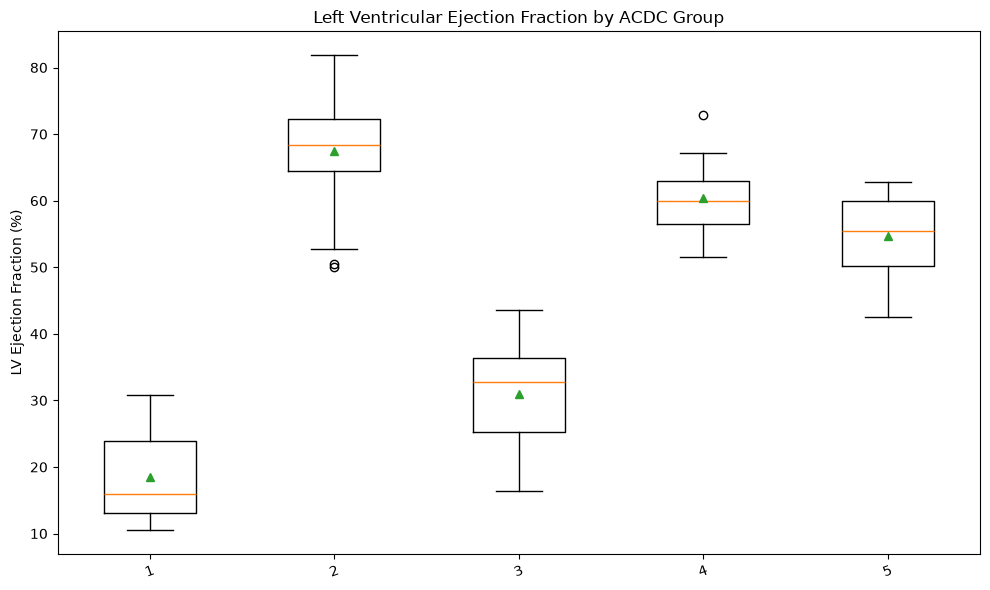

In [26]:
groups = results_df["Group_Name"].unique()

ef_data = [
    results_df[
        results_df["Group_Name"] == group
    ]["LV_EF"]
    for group in groups
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    ef_data,
    label=groups,
    showmeans=True
)

plt.ylabel("LV Ejection Fraction (%)")
plt.title("Left Ventricular Ejection Fraction by ACDC Group")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

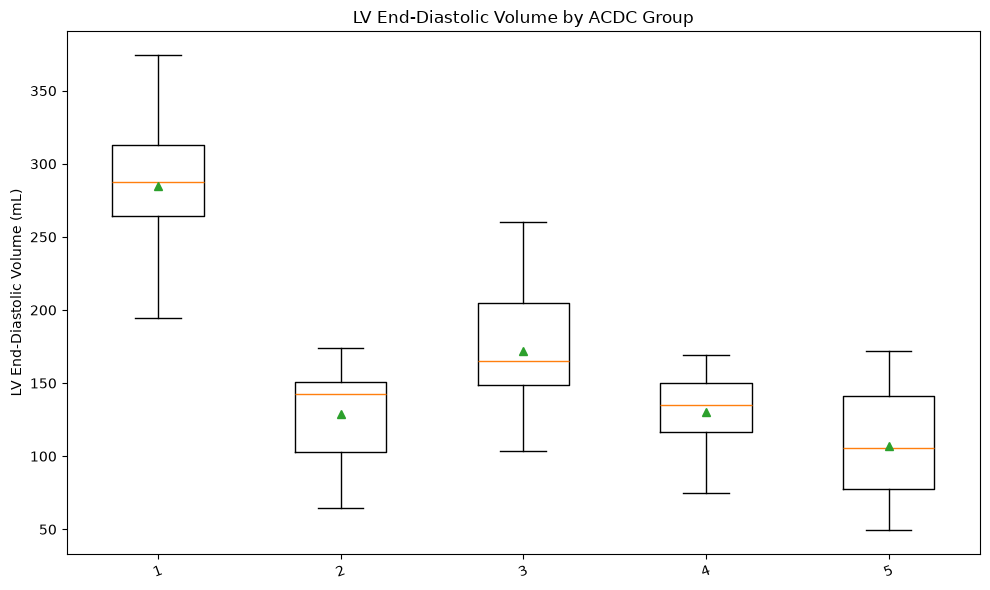

In [27]:
edv_data = [
    results_df[
        results_df["Group_Name"] == group
    ]["LV_EDV"]
    for group in groups
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    edv_data,
    label=groups,
    showmeans=True
)

plt.ylabel("LV End-Diastolic Volume (mL)")
plt.title("LV End-Diastolic Volume by ACDC Group")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

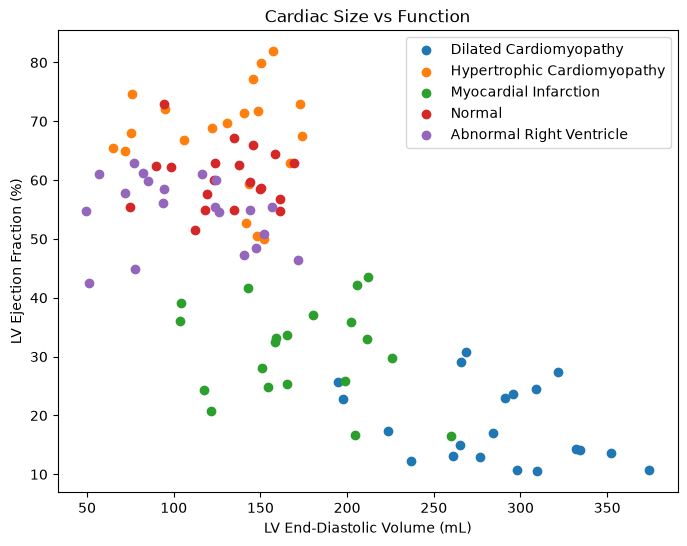

In [28]:
plt.figure(figsize=(8, 6))

for group in results_df["Group_Name"].unique():

    tmp = results_df[
        results_df["Group_Name"] == group
    ]

    plt.scatter(
        tmp["LV_EDV"],
        tmp["LV_EF"],
        label=group
    )

plt.xlabel("LV End-Diastolic Volume (mL)")
plt.ylabel("LV Ejection Fraction (%)")

plt.title(
    "Cardiac Size vs Function"
)

plt.legend()
plt.show()

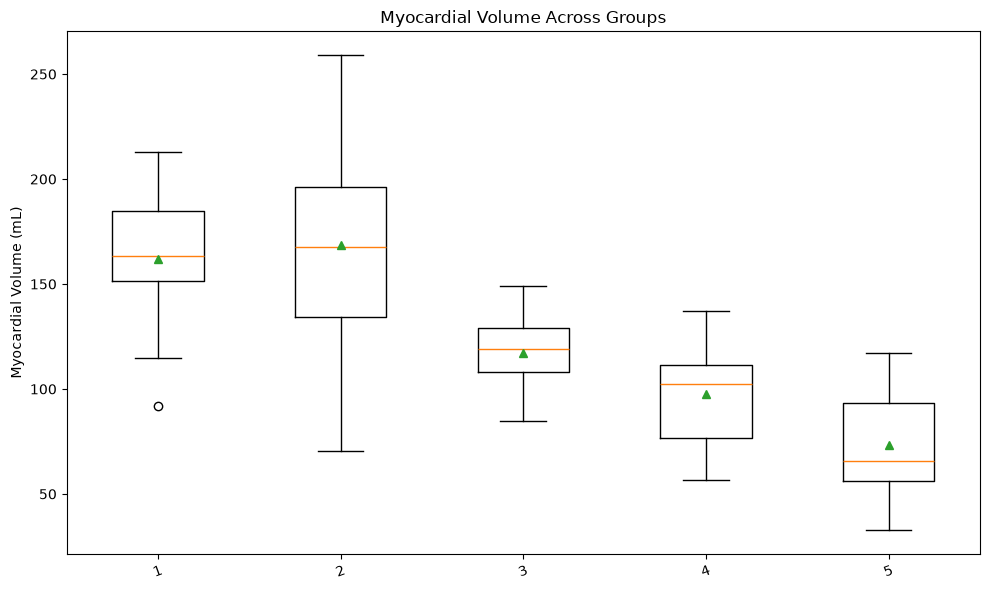

In [29]:
myo_data = [
    results_df[
        results_df["Group_Name"] == group
    ]["MYO_ED_Volume"]
    for group in groups
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    myo_data,
    label=groups,
    showmeans=True
)

plt.ylabel("Myocardial Volume (mL)")
plt.title("Myocardial Volume Across Groups")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [30]:
def representative_patient(
    df,
    group,
    metric="LV_EF"
):
    group_df = df[
        df["Group_Name"] == group
    ].copy()

    group_median = group_df[metric].median()

    group_df["distance_from_median"] = (
        group_df[metric] - group_median
    ).abs()

    return (
        group_df
        .sort_values("distance_from_median")
        .iloc[0]
    )

In [31]:
representatives = {}

for group in results_df["Group_Name"].unique():

    representatives[group] = (
        representative_patient(
            results_df,
            group,
            metric="LV_EF"
        )
    )

representatives

{'Dilated Cardiomyopathy': Patient                             patient008
 Group                                      DCM
 LV_EDV                              284.228516
 LV_ESV                              235.986328
 LV_SV                                48.242188
 LV_EF                                16.973029
 RV_EDV                              163.574219
 RV_ESV                               85.424805
 RV_SV                                78.149414
 RV_EF                                47.776119
 MYO_ED_Volume                       158.325195
 MYO_ES_Volume                       182.885742
 Group_Name              Dilated Cardiomyopathy
 distance_from_median                  0.998847
 Name: 7, dtype: object,
 'Hypertrophic Cardiomyopathy': Patient                                  patient023
 Group                                           HCM
 LV_EDV                                    75.452087
 LV_ESV                                    24.189789
 LV_SV                            

In [32]:
representative_rows = []

for group, patient in representatives.items():

    representative_rows.append({
        "Group": group,
        "Patient": patient["Patient"],
        "LV_EDV": patient["LV_EDV"],
        "LV_ESV": patient["LV_ESV"],
        "LV_EF": patient["LV_EF"]
    })

representative_df = pd.DataFrame(
    representative_rows
)

representative_df

,Group,Patient,LV_EDV,LV_ESV,LV_EF
0,Dilated Cardiomyopathy,patient008,284.228516,235.986328,16.973029
1,Hypertrophic Cardiomyopathy,patient023,75.452087,24.189789,67.940199
2,Myocardial Infarction,patient042,211.596680,141.610336,33.075350
3,Normal,patient068,123.486328,49.291992,60.083037
4,Abnormal Right Ventricle,patient081,156.801742,69.847305,55.455020


In [33]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

LV = 3

# Update these if your Group column uses different abbreviations
GROUPS_TO_COMPARE = {
    "Normal": "NOR",
    "Dilated Cardiomyopathy": "DCM",
    "Hypertrophic Cardiomyopathy": "HCM"
}

In [34]:
# Selecting a representative patient from each group

def representative_patient(df, group_code, metric="LV_EF"):
    """
    Select the patient whose value is closest to the group median
    for the specified metric.
    """

    group_df = df[df["Group"] == group_code].copy()

    if len(group_df) == 0:
        raise ValueError(f"No patients found for group {group_code}")

    group_median = group_df[metric].median()

    group_df["Distance_From_Median"] = (
        group_df[metric] - group_median
    ).abs()

    return (
        group_df
        .sort_values("Distance_From_Median")
        .iloc[0]
    )

In [35]:
representatives = {}

for display_name, group_code in GROUPS_TO_COMPARE.items():
    representatives[display_name] = representative_patient(
        results_df,
        group_code,
        metric="LV_EF"
    )


In [36]:
representative_rows = []

for display_name, patient in representatives.items():

    representative_rows.append({
        "Group": display_name,
        "Patient": patient["Patient"],
        "LV_EDV_mL": patient["LV_EDV"],
        "LV_ESV_mL": patient["LV_ESV"],
        "LV_SV_mL": patient["LV_SV"],
        "LV_EF_percent": patient["LV_EF"],
        "RV_EDV_mL": patient["RV_EDV"],
        "RV_ESV_mL": patient["RV_ESV"],
        "RV_SV_mL": patient["RV_SV"],
        "RV_EF_percent": patient["RV_EF"]
    })


representative_df = pd.DataFrame(representative_rows)

representative_df.to_csv(
    OUTPUT_DIR / "representative_hearts.csv",
    index=False
)

display(representative_df)

,Group,Patient,LV_EDV_mL,LV_ESV_mL,LV_SV_mL,LV_EF_percent,RV_EDV_mL,RV_ESV_mL,RV_SV_mL,RV_EF_percent
0,Normal,patient068,123.486328,49.291992,74.194336,60.083037,124.926758,57.592773,67.333984,53.898769
1,Dilated Cardiomyopathy,patient008,284.228516,235.986328,48.242188,16.973029,163.574219,85.424805,78.149414,47.776119
2,Hypertrophic Cardiomyopathy,patient023,75.452087,24.189789,51.262299,67.940199,64.694107,32.942398,31.751709,49.079755


In [37]:
def load_lv_phase(patient_id, phase):
    """
    Loads the LV mask for either ED or ES and converts it to a mesh.

    phase should be "ED" or "ES".
    """

    patient_dir = DATA_DIR / patient_id

    info = read_patient_info(patient_dir)

    frame = int(info[phase])

    gt_path = (
        patient_dir /
        f"{patient_id}_frame{frame:02d}_gt.nii.gz"
    )

    gt_img = nib.load(gt_path)
    gt = gt_img.get_fdata()

    spacing = gt_img.header.get_zooms()[:3]

    lv_mask = gt == LV

    verts, faces = mask_to_mesh(
        lv_mask,
        spacing
    )

    return {
        "verts": verts,
        "faces": faces,
        "frame": frame,
        "spacing": spacing
    }



In [38]:
heart_meshes = {}

for group_name, patient in representatives.items():

    patient_id = patient["Patient"]

    heart_meshes[group_name] = {
        "ED": load_lv_phase(patient_id, "ED"),
        "ES": load_lv_phase(patient_id, "ES")
    }

In [39]:
def center_vertices(verts):
    center = (
        verts.min(axis=0) +
        verts.max(axis=0)
    ) / 2

    return verts - center


all_centered_vertices = []

for group_name in heart_meshes:

    for phase in ["ED", "ES"]:

        verts = heart_meshes[group_name][phase]["verts"]

        centered = center_vertices(verts)

        heart_meshes[group_name][phase]["centered_verts"] = centered

        all_centered_vertices.append(centered)

In [40]:
all_vertices = np.vstack(all_centered_vertices)

max_extent = np.max(np.abs(all_vertices))

axis_range = [
    -max_extent * 1.10,
     max_extent * 1.10
]

In [43]:
from plotly.subplots import make_subplots

In [44]:
# ============================================================
# Build 3D comparison figure
#
# Columns:
# Normal | DCM | HCM
#
# Rows:
# ED
# ES
# ============================================================

group_names = list(GROUPS_TO_COMPARE.keys())

subplot_titles = []

for group in group_names:
    patient = representatives[group]

    subplot_titles.append(
        f"{group}<br>"
        f"ED | {patient['Patient']} | "
        f"EDV {patient['LV_EDV']:.1f} mL"
    )

for group in group_names:
    patient = representatives[group]

    subplot_titles.append(
        f"{group}<br>"
        f"ES | {patient['Patient']} | "
        f"ESV {patient['LV_ESV']:.1f} mL"
    )


fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
        [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]
    ],
    subplot_titles=subplot_titles,
    vertical_spacing=0.08,
    horizontal_spacing=0.03
)

In [45]:
# ============================================================
# Add mesh traces
# ============================================================

for col, group_name in enumerate(group_names, start=1):

    # --------------------
    # End Diastole
    # --------------------

    ed = heart_meshes[group_name]["ED"]

    verts = ed["centered_verts"]
    faces = ed["faces"]

    fig.add_trace(
        go.Mesh3d(
            x=verts[:, 0],
            y=verts[:, 1],
            z=verts[:, 2],

            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],

            opacity=0.80,

            name=f"{group_name} ED",

            hovertemplate=(
                f"{group_name}<br>"
                "End Diastole"
                "<extra></extra>"
            ),

            showscale=False
        ),
        row=1,
        col=col
    )


    # --------------------
    # End Systole
    # --------------------

    es = heart_meshes[group_name]["ES"]

    verts = es["centered_verts"]
    faces = es["faces"]

    fig.add_trace(
        go.Mesh3d(
            x=verts[:, 0],
            y=verts[:, 1],
            z=verts[:, 2],

            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],

            opacity=0.80,

            name=f"{group_name} ES",

            hovertemplate=(
                f"{group_name}<br>"
                "End Systole"
                "<extra></extra>"
            ),

            showscale=False
        ),
        row=2,
        col=col
    )

In [46]:
scene_settings = dict(
    xaxis=dict(
        range=axis_range,
        visible=False
    ),
    yaxis=dict(
        range=axis_range,
        visible=False
    ),
    zaxis=dict(
        range=axis_range,
        visible=False
    ),

    aspectmode="cube",

    camera=dict(
        eye=dict(
            x=1.4,
            y=1.4,
            z=1.1
        )
    )
)


for i in range(1, 7):

    scene_name = "scene" if i == 1 else f"scene{i}"

    fig.layout[scene_name].update(
        scene_settings
    )

In [47]:
fig.update_layout(
    title=dict(
        text=(
            "Representative Left Ventricles Across Cardiac Phenotypes"
            "<br>"
            "<sup>End Diastole → End Systole</sup>"
        ),
        x=0.5
    ),

    height=900,
    width=1300,

    showlegend=False,

    margin=dict(
        l=20,
        r=20,
        t=110,
        b=20
    )
)


fig.show()

# Save interactive version

html_path = (
    OUTPUT_DIR /
    "representative_hearts_3d_comparison.html"
)

fig.write_html(html_path)

print(
    "Saved interactive 3D comparison to:",
    html_path
)

Saved interactive 3D comparison to: ../outputs/representative_hearts_3d_comparison.html


In [48]:
png_path = (
    OUTPUT_DIR /
    "representative_hearts_3d_comparison.png"
)

try:

    fig.write_image(
        png_path,
        width=1600,
        height=1100,
        scale=2
    )

    print(
        "Saved static comparison to:",
        png_path
    )

except Exception as e:

    print(
        "\nPNG was not saved."
        "\nInstall Kaleido if you want static Plotly images:"
        "\npython -m pip install kaleido"
    )

Saved static comparison to: ../outputs/representative_hearts_3d_comparison.png


In [50]:
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Bar(
        x=["A", "B"],
        y=[1, 2]
    )
)

fig.write_image("../outputs/test_plot.png")